In [1]:

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


Dataset salvo como ..\datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 986
  1 (amarelo): 1493
  2 (vermelho): 1960
  3 (preto): 561


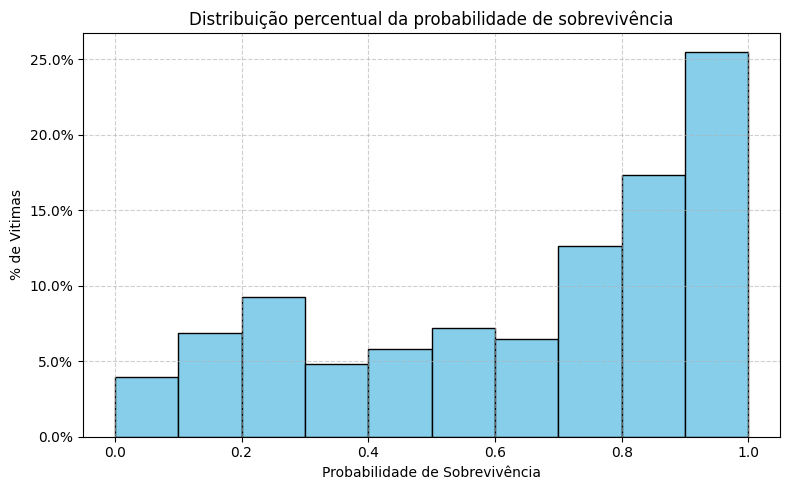

In [21]:
from collections import Counter
import sys
import os

sys.path.append(os.path.abspath("data_creation"))
from gerar_dados_vitimas import gerar_dataset_vitimas


# Parâmetros do dataset (fixos para o trabalho)
N_VITIMAS = 5000
MEDIA_IDADE = 45
DESVIO_IDADE = 5
TIPO_ACIDENTE = "aereo"
NIVEL_RUIDO = 0.05
SEED_TREINO = 50
SEED_TESTE = 89

# Dataset de treino/validação
df_treino_val = gerar_dataset_vitimas(
    n_vitimas=N_VITIMAS,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TREINO
)

In [22]:
print("Formato do dataset:", df_treino_val.shape)

print(df_treino_val.dtypes)

display(df_treino_val.head())

display(df_treino_val.describe())

Formato do dataset: (5000, 14)
idade      int64
fc         int64
fr         int64
pas        int64
spo2       int64
temp     float64
pr         int64
sg         int64
fx         int64
queim      int64
gcs        int64
avpu       int64
tri        int64
sobr     float64
dtype: object


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
0,45,110,25,101,96,38.333403,0,2,1,0,13,0,1,0.78
1,44,102,22,95,93,37.832716,0,1,1,0,13,0,1,0.77
2,51,123,22,100,93,37.730317,1,2,1,0,13,0,1,0.88
3,49,105,23,95,93,38.642985,0,1,0,1,13,1,1,0.72
4,41,124,23,108,96,36.736453,0,1,0,0,13,1,1,0.85


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,44.62080,104.896800,25.586400,82.965800,82.999800,35.422750,0.336400,1.971200,0.803600,0.818600,11.253200,1.265800,1.419200,0.644196
std,5.55143,42.853698,12.461813,33.437569,18.724987,2.642484,0.472525,1.194929,0.397314,1.212596,3.178224,1.043536,0.928679,0.293845
min,21.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,41.00000,89.000000,18.000000,70.000000,80.000000,34.276621,0.000000,1.000000,1.000000,0.000000,10.000000,0.000000,1.000000,0.397500
50%,45.00000,113.000000,26.000000,88.000000,88.000000,35.637921,0.000000,3.000000,1.000000,0.000000,11.000000,2.000000,2.000000,0.750000
75%,48.00000,136.000000,36.000000,106.000000,94.000000,37.376235,1.000000,3.000000,1.000000,2.000000,13.000000,2.000000,2.000000,0.900000
max,65.00000,169.000000,46.000000,139.000000,100.000000,39.320738,1.000000,3.000000,1.000000,3.000000,15.000000,3.000000,3.000000,1.000000


In [23]:
print("Distribuição da variável alvo (tri):")
print(df_treino_val["tri"].value_counts().sort_index())

print("\nDistribuição percentual:")
print(df_treino_val["tri"].value_counts(normalize=True).sort_index() * 100)

Distribuição da variável alvo (tri):
tri
0     986
1    1493
2    1960
3     561
Name: count, dtype: int64

Distribuição percentual:
tri
0    19.72
1    29.86
2    39.20
3    11.22
Name: proportion, dtype: float64


In [24]:
# variável alvo (target)
y = df_treino_val["tri"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X = df_treino_val.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X.columns))

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X: (5000, 10)
Formato de y: (5000,)


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import numpy as np

In [26]:
# Parâmetros

k_folds = 5
num_params = 3          # num de parametrizacoes a treinar
max_depth=[2, 4, 16]
min_samples_leaf=[1, 5, 10] 
criterion = ["gini", "gini", "entropy"]

# Validação cruzada
skf = StratifiedKFold( n_splits=k_folds, shuffle=True, random_state=42)

# Vars para salvar resultados
train_scores=[]
vld_scores=[]
modelos_cart = []

In [27]:
for i in range(num_params):

    f1_treino_folds = []
    f1_vali_folds = []

    for treino_index, vali_index in skf.split(X,y):

        X_treino_fold = X.iloc[treino_index]
        X_vali_fold = X.iloc[vali_index]
        y_treino_fold = y.iloc[treino_index]
        y_val_fold = y.iloc[vali_index]

        # Criar modelo com a parametrização i
        
        dt = DecisionTreeClassifier(
            max_depth=max_depth[i],
            min_samples_leaf=min_samples_leaf[i],
            criterion=criterion[i],
            random_state=42
        )

        # Treinar
        dt.fit(X_treino_fold, y_treino_fold)

        # Previsões
        y_pred_treino = dt.predict(X_treino_fold)
        y_pred_vali = dt.predict(X_vali_fold)

        # Calcular f1-score
        f1_treino = f1_score(y_treino_fold, y_pred_treino, average="macro")
        f1_vali = f1_score(y_val_fold, y_pred_vali, average="macro")

        f1_treino_folds.append(f1_treino)
        f1_vali_folds.append(f1_vali)

    #salvar Resultador da parametrização
    train_scores.append(f1_treino_folds)
    vld_scores.append(f1_vali_folds)
    modelos_cart.append(dt)





In [28]:
print("F1 treino por parametrização:")
print(train_scores)

print("\nF1 validação por parametrização:")
print(vld_scores)

F1 treino por parametrização:
[[0.6682215258718649, 0.9373139214664119, 0.6685145854999381, 0.6688564915084529, 0.9414175860279654], [0.943259900923044, 0.9373139214664119, 0.9418821477312571, 0.9386778420573552, 0.9414175860279654], [0.943259900923044, 0.9373139214664119, 0.9418821477312571, 0.9386778420573552, 0.9414175860279654]]

F1 validação por parametrização:
[[0.665681700260998, 0.9531107992286844, 0.6643941012699677, 0.6630032365252264, 0.9369082322102456], [0.9293218494804747, 0.9531107992286844, 0.9349751750051574, 0.9474926219759625, 0.9369082322102456], [0.9293218494804747, 0.9531107992286844, 0.9349751750051574, 0.9474926219759625, 0.9369082322102456]]


In [29]:
resultados = []

for i in range(num_params):

    f1_treino = train_scores[i]
    f1_vali = vld_scores[i]

    media_treino = np.mean(f1_treino)
    media_vali = np.mean(f1_vali)

    var_treino = np.var(f1_treino)
    var_vali = np.var(f1_vali)

    diff_f1 = abs(media_treino - media_vali)
    diff_var = abs(var_treino - var_vali)

    resultados.append({
        "max_depth": max_depth[i],
        "min_samples_leaf": min_samples_leaf[i],
        "criterion": criterion[i],
        "f1_treino_medio": media_treino,
        "f1_val_medio": media_vali,
        "diff_f1": diff_f1,
        "var_treino": var_treino,
        "var_vali": var_vali,
        "diff_var": diff_var
    })

df_resultados_cart = pd.DataFrame(resultados)

display(df_resultados_cart)

,max_depth,min_samples_leaf,criterion,f1_treino_medio,f1_val_medio,diff_f1,var_treino,var_vali,diff_var
0,2,1,gini,0.776865,0.776620,0.000245,0.017606,0.018930,0.001324
1,4,5,gini,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070
2,16,10,entropy,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070


In [30]:
#Selecionando os melhores parâmetros
df_resultados_cart = df_resultados_cart.sort_values(by="f1_val_medio", ascending=False)

melhores_params = df_resultados_cart.iloc[0]

# Criando o melhor modelo
melhor_cart_modelo = DecisionTreeClassifier(
    max_depth=melhores_params["max_depth"],
    min_samples_leaf=melhores_params["min_samples_leaf"],
    criterion=melhores_params["criterion"],
    random_state=42
)

# Treinando com TODOS os dados
melhor_cart_modelo.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(4)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",np.int64(5)
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

Agora vamos para a parte de Rede Neural -> MLP (Multiplayer Perceptron)

Entrada -> Camada Oculta -> (ou mais camadas) -> Saída

In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [32]:
# Parâmetros da MLP

num_params_mlp = 3

layers_escondidos = [(10,), (20,), (20,10)]
ativacao = ["relu", "relu", "tanh"]
aprendizado_rate_init = [0.001, 0.01, 0.001]

# Listas para armazerar resultados
treino_scores_mlp = []
vali_scores_mlp = []
modelos_mlp = []

In [33]:
for i in range(num_params_mlp):

    f1_treino_folds_mlp = []
    f1_vali_folds_mlp = []

    for treino_index_mlp, vali_index_mlp in skf.split(X, y):

        X_treino_fold_mlp = X.iloc[treino_index_mlp]
        X_vali_fold_mlp = X.iloc[vali_index_mlp]
        y_treino_fold_mlp = y.iloc[treino_index_mlp]
        y_vali_fold_mlp = y.iloc[vali_index_mlp] 

        #normalização
        scaler = StandardScaler()
        X_treino_fold_mlp = scaler.fit_transform(X_treino_fold_mlp)
        X_vali_fold_mlp = scaler.transform(X_vali_fold_mlp)

        # Criando modelo MLP com a parametrização i

        mlp = MLPClassifier(
            hidden_layer_sizes=layers_escondidos[i],
            activation=ativacao[i],
            learning_rate_init=aprendizado_rate_init[i],
            max_iter=500,
            random_state=42
        )

        # Treinar
        mlp.fit(X_treino_fold_mlp, y_treino_fold_mlp)

        # Previsões
        y_pred_treino_mlp = mlp.predict(X_treino_fold_mlp)
        y_pred_vali_mlp = mlp.predict(X_vali_fold_mlp)

        # f1-score

        f1_treino_mlp = f1_score(y_treino_fold_mlp, y_pred_treino_mlp, average="macro")
        f1_vali_mlp = f1_score(y_vali_fold_mlp, y_pred_vali_mlp, average="macro")

        f1_treino_folds_mlp.append(f1_treino_mlp)
        f1_vali_folds_mlp.append(f1_vali_mlp)
    
    treino_scores_mlp.append(f1_treino_folds_mlp)
    vali_scores_mlp.append(f1_vali_folds_mlp)
    modelos_mlp.append(mlp)

c:\Users\DAGEE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [34]:
resultados_mlp = []

for i in range(num_params_mlp):
    f1_treino_mlp = treino_scores_mlp[i]
    f1_vali_mlp = vali_scores_mlp[i]

    media_treino_mlp = np.mean(f1_treino_mlp)
    media_vali_mlp = np.mean(f1_vali_mlp)  

    var_treino_mlp = np.var(f1_treino_mlp)
    var_vali_mlp = np.var(f1_vali_mlp)

    diff_f1_mlp = abs(media_treino_mlp - media_vali_mlp)
    diff_var_mlp = abs(var_treino_mlp - var_vali_mlp)

    resultados_mlp.append({
        "hidden_layers": layers_escondidos[i],
        "activation": ativacao[i],
        "learning_rate": aprendizado_rate_init[i],
        "f1_train_medio": media_treino_mlp,
        "f1_val_medio": media_vali_mlp,
        "diff_f1": diff_f1_mlp,
        "var_train": var_treino_mlp,
        "var_val": var_vali_mlp,
        "diff_var": diff_var_mlp        
    })  

df_resultados_mlp = pd.DataFrame(resultados_mlp)

display(df_resultados_mlp)

,hidden_layers,activation,learning_rate,f1_train_medio,f1_val_medio,diff_f1,var_train,var_val,diff_var
0,"(10,)",relu,0.001,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070
1,"(20,)",relu,0.010,0.940564,0.940145,0.000419,0.000005,0.000080,0.000075
2,"(20, 10)",tanh,0.001,0.940724,0.940213,0.000511,0.000006,0.000076,0.000071


In [35]:
df_resultados_mlp = df_resultados_mlp.sort_values(by="f1_val_medio",ascending=False)

# Selecionar melhor parametrização
melhor_mlp_params = df_resultados_mlp.iloc[0]

# Criar modelo final MLP
melhor_mlp_modelo = MLPClassifier(
    hidden_layer_sizes=melhor_mlp_params["hidden_layers"],
    activation=melhor_mlp_params["activation"],
    learning_rate_init=melhor_mlp_params["learning_rate"],
    max_iter=500,
    random_state=42
)

#normalização antes do treino
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

# Treinar com todos os dados
melhor_mlp_modelo.fit(X_scaled, y)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",np.float64(0.001)
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [36]:
display(df_resultados_cart)

,max_depth,min_samples_leaf,criterion,f1_treino_medio,f1_val_medio,diff_f1,var_treino,var_vali,diff_var
1,4,5,gini,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070
2,16,10,entropy,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070
0,2,1,gini,0.776865,0.776620,0.000245,0.017606,0.018930,0.001324


Comparação entre os dois

In [37]:
melhor_cart = df_resultados_cart.iloc[0]
melhor_mlp = df_resultados_mlp.iloc[0]

comparacao = pd.DataFrame({
    "Modelo": ["CART", "MLP"],
    "f1_treino": [
        melhor_cart["f1_treino_medio"],
        melhor_mlp["f1_train_medio"]
    ],
    "f1_validacao": [
        melhor_cart["f1_val_medio"],
        melhor_mlp["f1_val_medio"]
    ],
    "diff_f1": [
        melhor_cart["diff_f1"],
        melhor_mlp["diff_f1"]
    ],
    "var_validacao": [
        melhor_cart["var_vali"],
        melhor_mlp["var_val"]
    ]
})

display(comparacao)

,Modelo,f1_treino,f1_validacao,diff_f1,var_validacao
0,CART,0.94051,0.940362,0.000149,0.000075
1,MLP,0.94051,0.940362,0.000149,0.000075


TESTE CEGO - gerar o dataset como 1000 vítimas, refazer Cart e MLP


Dataset salvo como ..\datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 205
  1 (amarelo): 289
  2 (vermelho): 374
  3 (preto): 132


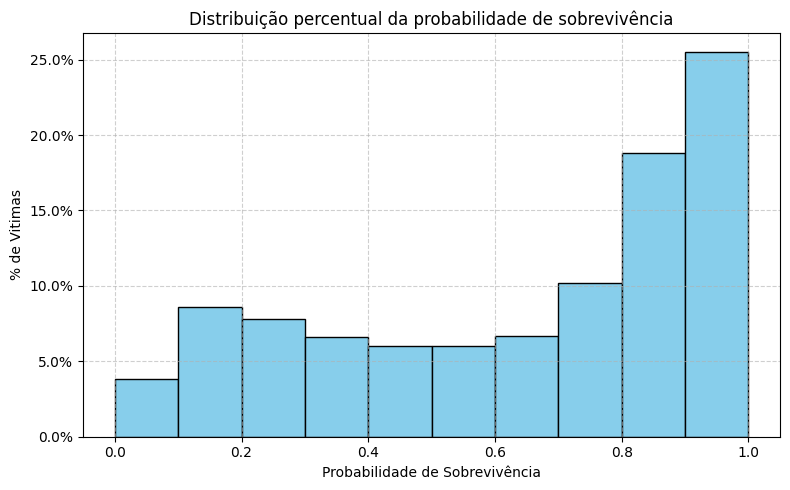

In [38]:
#Gerando um data set com 1000 vítimas, e seed diferente da de treino

df_teste = gerar_dataset_vitimas(
    n_vitimas=1000,
    media_idade=45,
    desvio_idade=5,
    tipo_acidente="aereo",
    nivel_ruido=0.05,
    seed=89 
)

In [39]:
y_teste = df_teste["tri"]

X_teste = df_teste.drop(columns=["gcs", "avpu", "tri", "sobr"])

In [40]:
y_pred_cart = melhor_cart_modelo.predict(X_teste)

In [41]:
from sklearn.metrics import classification_report

print("CART:")
print(classification_report(y_teste, y_pred_cart))

CART:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       205
           1       0.94      0.98      0.96       289
           2       0.95      0.98      0.96       374
           3       0.92      0.82      0.86       132

    accuracy                           0.94      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.94      0.94      0.94      1000



Teste Cego MLP

In [42]:
X_teste_scaled = scaler_final.transform(X_teste)

In [43]:
y_pred_mlp = melhor_mlp_modelo.predict(X_teste_scaled)

In [45]:
print("MLP:")
print(classification_report(y_teste, y_pred_mlp))

MLP:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       205
           1       0.94      0.98      0.96       289
           2       0.95      0.98      0.96       374
           3       0.92      0.82      0.86       132

    accuracy                           0.94      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.94      0.94      0.94      1000



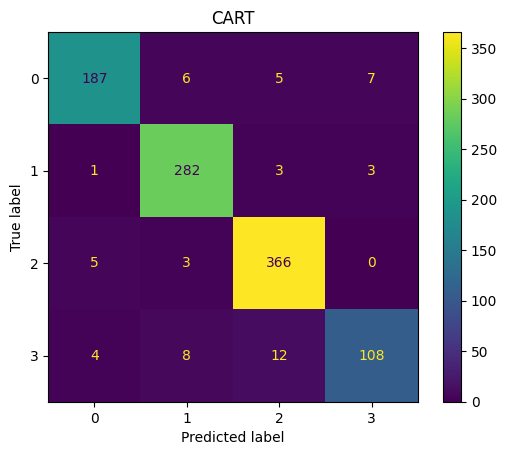

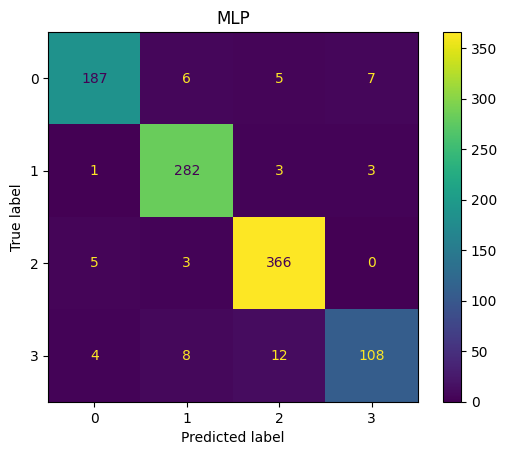

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_cart)
plt.title("CART")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_mlp)
plt.title("MLP")
plt.show()

In [47]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1_cart = f1_score(y_teste, y_pred_cart, average="macro")
precision_cart = precision_score(y_teste, y_pred_cart, average="macro")
recall_cart = recall_score(y_teste, y_pred_cart, average="macro")

f1_mlp = f1_score(y_teste, y_pred_mlp, average="macro")
precision_mlp = precision_score(y_teste, y_pred_mlp, average="macro")
recall_mlp = recall_score(y_teste, y_pred_mlp, average="macro")

comparacao_teste = pd.DataFrame({
    "Modelo": ["CART", "MLP"],
    "Precision": [precision_cart, precision_mlp],
    "Recall": [recall_cart, recall_mlp],
    "F1-score": [f1_cart, f1_mlp]
})

display(comparacao_teste)

,Modelo,Precision,Recall,F1-score
0,CART,0.938956,0.921191,0.929172
1,MLP,0.938956,0.921191,0.929172
